### Standard CNN-LSTM Model with feature engineered data - KFold and Optuna hyperparameter tuning

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, BatchNormalization, Input, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit

import optuna
import lime.lime_tabular as lime
import shap
from IPython.display import display, HTML

/Users/amalshar/miniforge3/envs/mlenv64/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
DATA_PATH = '/Users/amalshar/Desktop/USD/Fall 2025/Data Analysis/Final Project/daily_2025_engineered_data.csv'
TARGET = 'DailyAQI'

# Same feature set as your original CNN–LSTM
FEATURES = [
    'CO', 'SO2', 'NO2', 'O3', 'PM25',
    'BarometricPressure', 'Temperature', 'WindResultant',
    'month', 'dayofweek', 'is_weekend', 'dayofyear',
    'CO_roll_3', 'NO2_roll_3', 'PM25_roll_3', 'O3_roll_3'
]

TIME_STEPS = 7  # 7-day lookback

# %%
df = pd.read_csv(DATA_PATH)
df['Date Local'] = pd.to_datetime(df['Date Local'], errors='coerce')

# Drop rows with missing required columns
df = df.dropna(subset=FEATURES + [TARGET]).copy()

# Sort by time to maintain temporal order
df = df.sort_values('Date Local').reset_index(drop=True)

print("Rows after cleaning:", len(df))
print("Date range:", df['Date Local'].min(), "->", df['Date Local'].max())


Rows after cleaning: 91740
Date range: 2025-01-01 00:00:00 -> 2025-07-01 00:00:00


In [ ]:
X_raw = df[FEATURES].values
y_raw = df[[TARGET]].values   # shape (N, 1)

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X_raw)
y_scaled = scaler_y.fit_transform(y_raw)

# %%
def create_sequences(X, y, time_steps=7):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:i+time_steps])
        ys.append(y[i+time_steps])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = create_sequences(X_scaled, y_scaled, TIME_STEPS)
print("X_seq shape:", X_seq.shape, "| y_seq shape:", y_seq.shape)


X_seq shape: (91733, 7, 16) | y_seq shape: (91733, 1)


In [ ]:
n_seq = X_seq.shape[0]
train_end = int(0.7 * n_seq)
val_end   = int(0.8 * n_seq)

X_train, y_train = X_seq[:train_end],        y_seq[:train_end]
X_val,   y_val   = X_seq[train_end:val_end], y_seq[train_end:val_end]
X_test,  y_test  = X_seq[val_end:],          y_seq[val_end:]

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)


Train: (64213, 7, 16) Val: (9173, 7, 16) Test: (18347, 7, 16)


In [ ]:
def build_cnn_lstm_model(n_features, time_steps, trial):
    # Hyperparameters (Option A – fast & expressive)
    filters = trial.suggest_int("filters", 32, 128, step=32)
    kernel_size = trial.suggest_int("kernel_size", 2, 5)
    lstm_units = trial.suggest_int("lstm_units", 32, 128, step=32)
    dropout_rate = trial.suggest_float("dropout", 0.0, 0.4, step=0.1)
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)

    model = Sequential([
        Input(shape=(time_steps, n_features)),
        Conv1D(filters=filters, kernel_size=kernel_size, activation='relu'),
        MaxPooling1D(pool_size=2),
        BatchNormalization(),
        LSTM(lstm_units),
        BatchNormalization(),
        Dropout(dropout_rate),
        Dense(32, activation='relu'),
        Dense(1)
    ])

    opt = tf.keras.optimizers.Adam(learning_rate=lr)
    model.compile(optimizer=opt, loss='mse')
    return model

N_SPLITS = 3
EPOCHS_TUNE = 40
BATCH_SIZE_TUNE = 64

def objective(trial):
    tf.keras.backend.clear_session()

    n_features = X_train.shape[2]
    model = build_cnn_lstm_model(n_features, TIME_STEPS, trial)

    tscv = TimeSeriesSplit(n_splits=N_SPLITS)
    rmses = []

    for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train)):
        X_tr, X_v = X_train[tr_idx], X_train[val_idx]
        y_tr, y_v = y_train[tr_idx], y_train[val_idx]

        es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
        rlrop = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5, verbose=0)

        model.fit(
            X_tr, y_tr,
            validation_data=(X_v, y_v),
            epochs=EPOCHS_TUNE,
            batch_size=BATCH_SIZE_TUNE,
            callbacks=[es, rlrop],
            verbose=0
        )

        y_v_pred = model.predict(X_v, verbose=0)
        rmse = np.sqrt(mean_squared_error(y_v, y_v_pred))
        rmses.append(rmse)

    mean_rmse = float(np.mean(rmses))
    print(f"Trial {trial.number}: mean CV RMSE (scaled) = {mean_rmse:.4f}")
    return mean_rmse


In [ ]:
study = optuna.create_study(direction="minimize", study_name="CNN_LSTM_AQI_feature_engineered")
study.optimize(objective, n_trials=15, show_progress_bar=True)

print("\nBest trial:")
print("  Value (mean CV RMSE, scaled):", study.best_value)
print("  Params:", study.best_params)


[I 2025-11-25 16:30:30,591] A new study created in memory with name: CNN_LSTM_AQI_feature_engineered
Best trial: 0. Best value: 0.0325263:   7%|▋         | 1/15 [01:17<18:05, 77.51s/it]

Trial 0: mean CV RMSE (scaled) = 0.0325
[I 2025-11-25 16:31:48,132] Trial 0 finished with value: 0.03252628207893412 and parameters: {'filters': 128, 'kernel_size': 3, 'lstm_units': 64, 'dropout': 0.1, 'lr': 0.000301227761423546}. Best is trial 0 with value: 0.03252628207893412.


Best trial: 1. Best value: 0.0307903:  13%|█▎        | 2/15 [01:49<10:55, 50.45s/it]

Trial 1: mean CV RMSE (scaled) = 0.0308
[I 2025-11-25 16:32:19,634] Trial 1 finished with value: 0.030790325475674216 and parameters: {'filters': 32, 'kernel_size': 5, 'lstm_units': 32, 'dropout': 0.4, 'lr': 0.004596944055239764}. Best is trial 1 with value: 0.030790325475674216.


Best trial: 1. Best value: 0.0307903:  20%|██        | 3/15 [04:20<19:18, 96.54s/it]

...

Trial 12: mean CV RMSE (scaled) = 0.0322
[I 2025-11-25 16:45:42,081] Trial 12 finished with value: 0.03223440808584524 and parameters: {'filters': 96, 'kernel_size': 4, 'lstm_units': 64, 'dropout': 0.0, 'lr': 0.0015686592559900968}. Best is trial 9 with value: 0.030277157848467667.


Best trial: 9. Best value: 0.0302772:  93%|█████████▎| 14/15 [16:07<01:05, 65.51s/it]

Trial 13: mean CV RMSE (scaled) = 0.0315
[I 2025-11-25 16:46:38,184] Trial 13 finished with value: 0.0314561478145079 and parameters: {'filters': 128, 'kernel_size': 5, 'lstm_units': 96, 'dropout': 0.2, 'lr': 0.009731394911762711}. Best is trial 9 with value: 0.030277157848467667.


Best trial: 9. Best value: 0.0302772: 100%|██████████| 15/15 [17:20<00:00, 69.37s/it]

Trial 14: mean CV RMSE (scaled) = 0.0309
[I 2025-11-25 16:47:51,189] Trial 14 finished with value: 0.030940030038887317 and parameters: {'filters': 96, 'kernel_size': 4, 'lstm_units': 64, 'dropout': 0.1, 'lr': 0.002760646434058477}. Best is trial 9 with value: 0.030277157848467667.

Best trial:
  Value (mean CV RMSE, scaled): 0.030277157848467667
  Params: {'filters': 96, 'kernel_size': 4, 'lstm_units': 32, 'dropout': 0.2, 'lr': 0.007730550259313376}


In [ ]:
best_params = study.best_params
print("Best hyperparameters:", best_params)

tf.keras.backend.clear_session()

n_features = X_train.shape[2]
final_model = build_cnn_lstm_model(
    n_features,
    TIME_STEPS,
    trial=optuna.trial.FixedTrial(best_params)
)

# Train on Train + Val
X_train_full = np.concatenate([X_train, X_val], axis=0)
y_train_full = np.concatenate([y_train, y_val], axis=0)

es_final = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
rlrop_final = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5, verbose=1)

history = final_model.fit(
    X_train_full, y_train_full,
    validation_split=0.1,
    epochs=100,
    batch_size=best_params.get("batch_size", 64) if "batch_size" in best_params else 64,
    callbacks=[es_final, rlrop_final],
    verbose=1
)


Best hyperparameters: {'filters': 96, 'kernel_size': 4, 'lstm_units': 32, 'dropout': 0.2, 'lr': 0.007730550259313376}
Epoch 1/100
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0057 - val_loss: 3.4639e-04 - learning_rate: 0.0077
Epoch 2/100
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0013 - val_loss: 2.3547e-04 - learning_rate: 0.0077
Epoch 3/100
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0012 - val_loss: 2.5435e-04 - learning_rate: 0.0077
Epoch 4/100
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0011 - val_loss: 2.1157e-04 - learning_rate: 0.0077
Epoch 5/100
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0011 - val_loss: 1.8104e-04 - learning_rate: 0.0077
Epoch 6/100
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0011 - val_loss: 2.2567e-04 - learning_rate: 0.0077
Epoch 7/100
1014/1032 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0010
Epoch 7: ReduceLROnPlateau reducing learning rate to 0.00386527506634593.
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 2s 2m

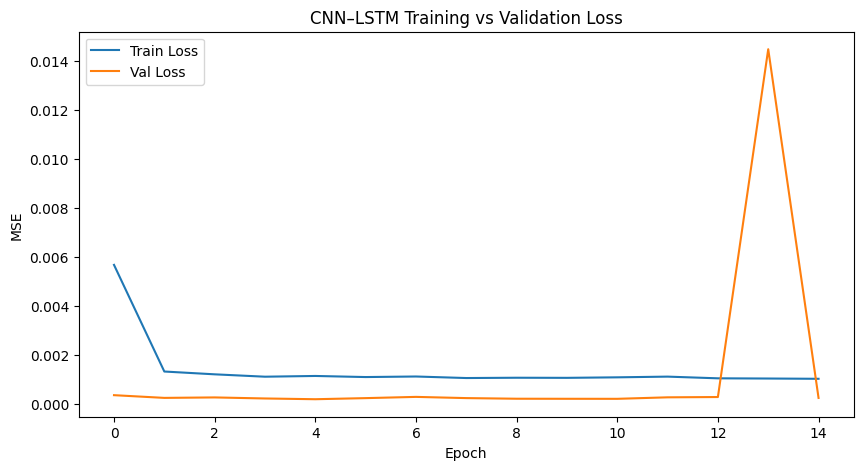

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("CNN–LSTM Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.show()


In [ ]:
def invert_target(y_scaled):
    y_inv = scaler_y.inverse_transform(y_scaled)
    return y_inv

# Predict on test
y_test_pred_scaled = final_model.predict(X_test, verbose=0)
y_pred = invert_target(y_test_pred_scaled)
y_true = invert_target(y_test)

mse  = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_true, y_pred)
mape = np.mean(np.abs((y_true - y_pred) / np.maximum(y_true, 1e-6))) * 100
r2   = r2_score(y_true, y_pred)

print(f"MSE: {mse:.3f} | RMSE: {rmse:.3f} | MAE: {mae:.3f} | MAPE: {mape:.2f}% | R²: {r2:.3f}")


MSE: 822.826 | RMSE: 28.685 | MAE: 18.304 | MAPE: 1943263.54% | R²: -0.039


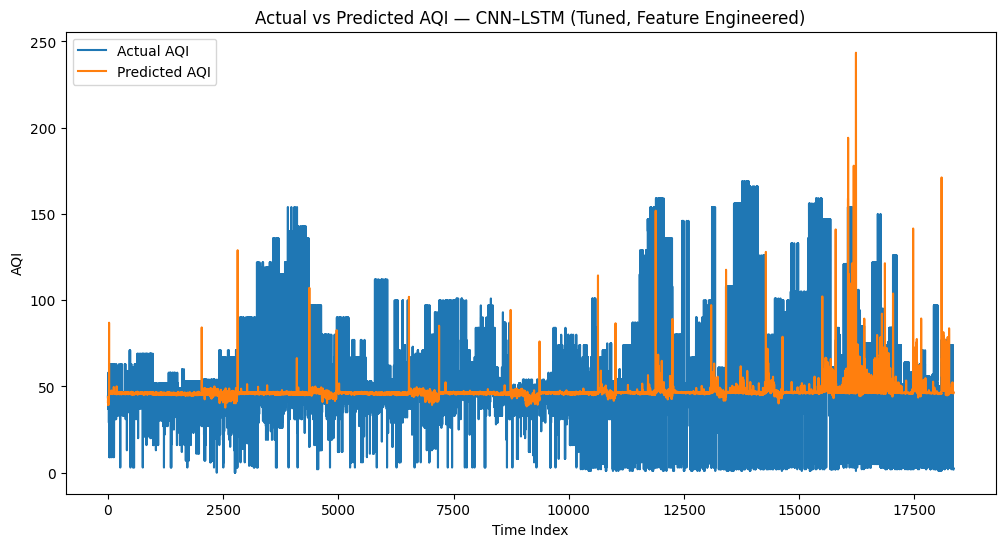

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(y_true, label="Actual AQI")
plt.plot(y_pred, label="Predicted AQI")
plt.title("Actual vs Predicted AQI — CNN–LSTM (Tuned, Feature Engineered)")
plt.xlabel("Time Index")
plt.ylabel("AQI")
plt.legend()
plt.show()



Permutation Importance (CNN–LSTM, R² drop):
               Feature  Importance
9            dayofweek    0.191753
10          is_weekend    0.143526
4                 PM25    0.004924
3                   O3    0.003638
13          NO2_roll_3    0.003175
15           O3_roll_3    0.002441
2                  NO2    0.002070
14         PM25_roll_3    0.001939
6          Temperature    0.001025
1                  SO2    0.000008
12           CO_roll_3   -0.000370
0                   CO   -0.000385
5   BarometricPressure   -0.000613
8                month   -0.001970
11           dayofyear   -0.002436


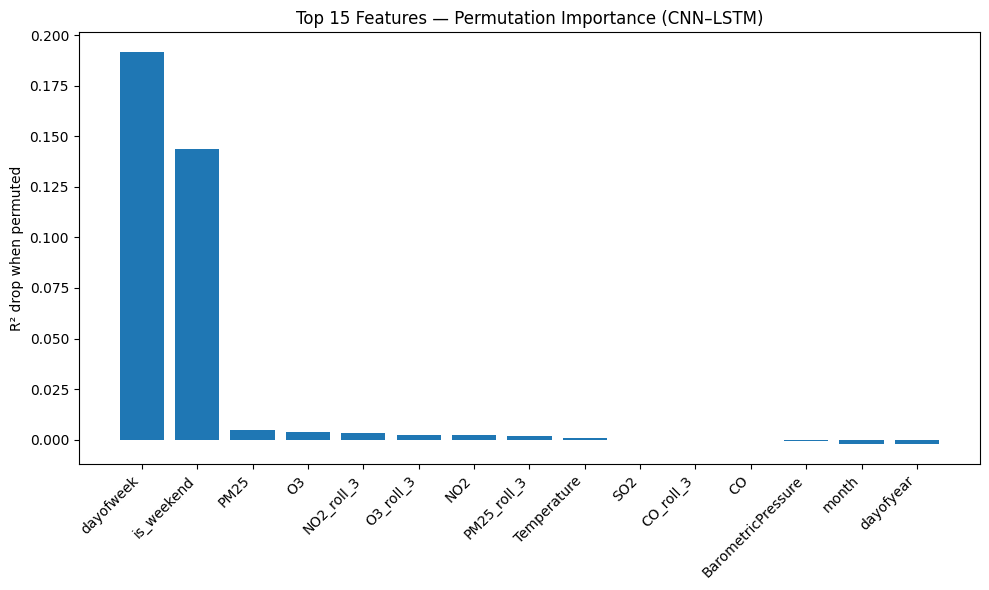

In [ ]:
def permutation_importance_cnn_lstm(model, X_test, y_true_orig, feature_names, n_repeats=3, metric=r2_score):
    baseline_pred_scaled = model.predict(X_test, verbose=0)
    baseline_pred = invert_target(baseline_pred_scaled)
    baseline_score = metric(y_true_orig, baseline_pred)

    importances = {}

    for j, feat in enumerate(feature_names):
        drops = []
        for _ in range(n_repeats):
            Xp = X_test.copy()
            perm_idx = np.random.permutation(Xp.shape[0])
            Xp[:, :, j] = Xp[perm_idx, :, j]

            perm_pred_scaled = model.predict(Xp, verbose=0)
            perm_pred = invert_target(perm_pred_scaled)
            score_perm = metric(y_true_orig, perm_pred)
            drops.append(baseline_score - score_perm)

        importances[feat] = float(np.mean(drops))

    return importances

feat_importances = permutation_importance_cnn_lstm(
    final_model,
    X_test,
    y_true,
    FEATURES,
    n_repeats=3
)

fi_df = pd.DataFrame(list(feat_importances.items()), columns=['Feature','Importance']) \
        .sort_values('Importance', ascending=False)

print("\nPermutation Importance (CNN–LSTM, R² drop):")
print(fi_df.head(15))

plt.figure(figsize=(10,6))
plt.bar(fi_df['Feature'][:15], fi_df['Importance'][:15])
plt.xticks(rotation=45, ha='right')
plt.ylabel("R² drop when permuted")
plt.title("Top 15 Features — Permutation Importance (CNN–LSTM)")
plt.tight_layout()
plt.show()


In [ ]:
# Flatten sequences for LIME
X_train_flat = X_train_full.reshape(X_train_full.shape[0], -1)
X_test_flat  = X_test.reshape(X_test.shape[0], -1)

feature_names_flat = [f"{feat}_t-{t}" for t in range(TIME_STEPS) for feat in FEATURES]

def predict_wrapper(flat_batch):
    reshaped = flat_batch.reshape(-1, TIME_STEPS, len(FEATURES))
    preds_scaled = final_model.predict(reshaped, verbose=0)
    preds = invert_target(preds_scaled)
    return preds.flatten()

lime_explainer = lime.LimeTabularExplainer(
    training_data=X_train_flat,
    feature_names=feature_names_flat,
    mode='regression'
)

i = 0  # first test instance
exp = lime_explainer.explain_instance(
    data_row=X_test_flat[i],
    predict_fn=predict_wrapper,
    num_features=12
)

try:
    display(HTML(exp.as_html()))
except Exception:
    print("LIME Explanation:")
    for feature, weight in exp.as_list():
        print(f"{feature}: {weight:.4f}")

with open("exp17_cnn_lstm_lime_explanation.html", "w") as f:
    f.write(exp.as_html())


100%|██████████| 10/10 [00:07<00:00,  1.31it/s]


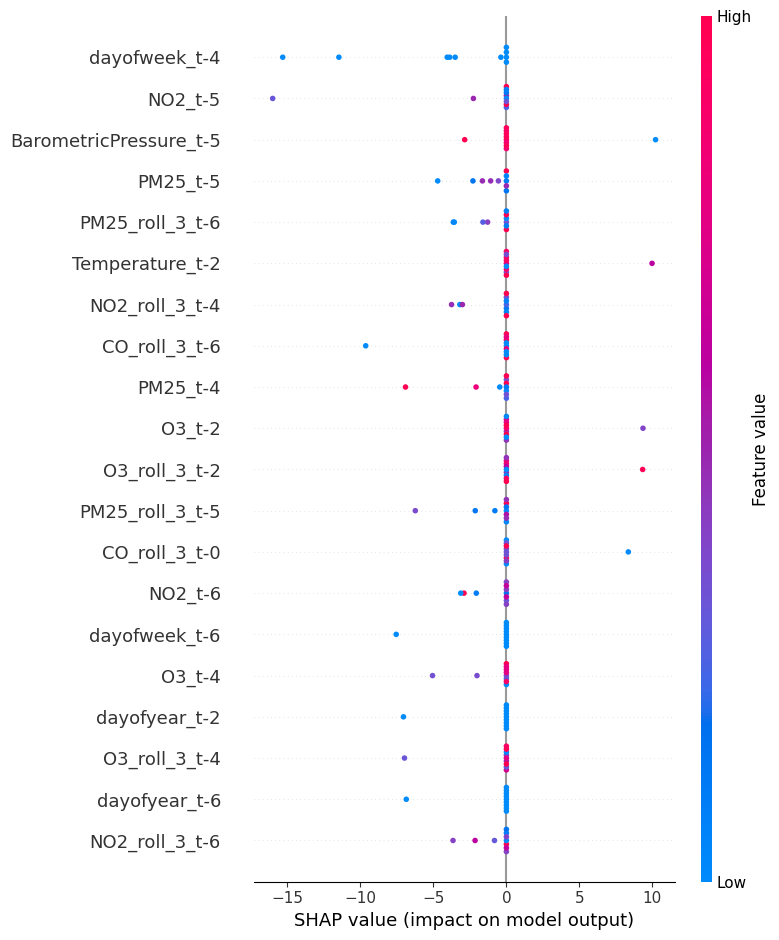

In [ ]:
background = X_train_flat[:100]
test_samples = X_test_flat[:10]

shap_explainer = shap.KernelExplainer(predict_wrapper, background)
shap_values = shap_explainer.shap_values(test_samples, nsamples=200)

shap.summary_plot(shap_values, test_samples, feature_names=feature_names_flat)
